# Introduction to DEA Water Observations Statistics <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with both the `NCI` and `DEA Sandbox` environments
* **Products used:** 
[ga_ls_wo_fq_cyear_3](https://explorer.dea.ga.gov.au/products/ga_ls_wo_fq_cyear_3),
[ga_ls_wo_fq_myear_3](https://explorer.dea.ga.gov.au/products/ga_ls_wo_fq_myear_3),
[ga_ls_wo_fq_nov_mar_3](https://explorer.dea.ga.gov.au/products/ga_ls_wo_fq_nov_mar_3),
[ga_ls_wo_fq_apr_oct_3](https://explorer.dea.ga.gov.au/products/ga_ls_wo_fq_apr_oct_3)


## Background

Digital Earth Australia (DEA) [Water Observations](https://knowledge.dea.ga.gov.au/data/product/dea-water-observations-landsat/) uses an algorithm to classify each pixel from Landsat satellite imagery as 'wet', 'dry' or 'invalid'. Combining the classified pixels into summaries, covering a year, season, or all of time (since 1986) gives the information on where water is usually, and where it is rarely.

DEA [Water Observations Statistics](https://knowledge.dea.ga.gov.au/data/product/dea-water-observations-statistics-landsat/) provides information on how many times the Landsat satellites were able to clearly see an area, how many times those observations were wet, and what that means for the percentage of time that water was observed in the landscape.

### What this product offers
Water Observations Statistics is available in multiple forms, depending on the length of time over which the statistics are calculated. At present the following are available:
- **DEA WO Multi-Year:** `ga_ls_wo_fq_myear_`3: statistics calculated from the full depth of time series (1986 to 2025) unfiltered
- **DEA WO Calendar Year:** `ga_ls_wo_fq_cyear_3`: statistics calculated from each calendar year (1986 to present)
- **DEA WO November to March:** `ga_ls_wo_fq_nov_mar_3`: statistics calculated yearly from November to March (1986 to present)
- **DEA WO April to October:** `ga_ls_wo_fq_apr_oct_3`: statistics calculated yearly from April to October (1986 to present)

Each dataset in this product suite consists of the following datasets:
- **Clear Count:** how many times an area could be clearly seen (i.e. not affected by clouds, shadows or other satellite observation problems)
- **Wet Count:** how many times water was detected in observations that were clear
- **Water Frequency:** what percentage of clear observations were detected as wet (i.e. the ratio of wet to clear as a percentage)

<div class="alert alert-info">

When loading the data of any Water Observations Statistics product using the datacube Python library or when using [DEA Maps](https://maps.dea.ga.gov.au/), the central date of the observation period is returned. This date typically corresponds to:

* 15 January for the November to March season
* 16 July for the April to October season
* 2 July for calendar year summaries

For example, the November to March 2020–2021 season is reported with a central date of 15 January 2021.

</div>

### Applications
- Helps understand where flooding may have occurred in the past, to inform emergency management and risk assessment.
- Provides an indication of the permanence of surface water in the Australian landscape by showing where water is observed rarely in comparison to where it is often observed, informing water management and mapping.
- Can assist with wetland analyses, water connectivity and surface-ground water relationships.
- The annual product provides information on how surface water changes per year across Australia, and is useful for drought analysis.
- The seasonal product is useful for understanding the differences in water availability between the summer and winter periods across Australia.

For applications that require water observations from specific satellite images, see instead the [Water Observations](https://github.com/GeoscienceAustralia/dea-notebooks/blob/develop/DEA_products/DEA_Water_Observations.ipynb) notebook.

### Publications
* Mueller, N., Lewis, A., Roberts, D., Ring, S., Melrose, R., Sixsmith, J., Lymburner, L., McIntyre, A., Tan, P., Curnow, S., & Ip, A. (2016). [Water observations from space: Mapping surface water from 25 years of Landsat imagery across Australia](https://doi.org/10.1016/j.rse.2015.11.003). Remote Sensing of Environment, 174, 341–352. 


## Description
This notebook will demonstrate how to load and analyse Water Observations Statistics using DEA, including:

1. Inspecting the products and measurements available in the datacube for Water Observations Statistics.
2. Load calendar year Water Observations Statistics for an example location.
3. Load the seasonal and multi-year Water Observations Statistics for the same location and compare them with the calendar year summary.
4. Example application: Use the calendar year Water Observations Statistics to extract annual shorelines of Lake George, ACT.

<div class="alert alert-info">
    
**Note:** Visit the [DEA Water Observations product documentation](https://knowledge.dea.ga.gov.au/data/product/dea-water-observations-statistics-landsat/) for detailed technical information including methods, quality, and data access.

</div>

---

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis.

In [1]:
import datacube
import xarray as xr
import pandas as pd
import seaborn as sb
import contextily as ctx
import matplotlib.pyplot as plt

import sys
sys.path.insert(1, '../Tools/')
from dea_tools.spatial import subpixel_contours

### Connect to the datacube

Connect to the datacube so we can access DEA data.

In [2]:
dc = datacube.Datacube(app='DEA_Water_Observations_Statistics')

## Available products and measurements

### List products available in DEA
We can use datacube's `list_products` functionality to inspect Water Observations Statistics products that are available in DEA.
The table below shows the product name that we will use to load data, and a brief description of the product.

In [3]:
# List Water Observations Statistics products available in DEA
dc_products = dc.list_products()
dc_products[dc_products["name"].str.contains("ga_ls_wo_fq")]

,name,description,license,default_crs,default_resolution
name,,,,,
ga_ls_wo_fq_apr_oct_3,ga_ls_wo_fq_apr_oct_3,Geoscience Australia Landsat Water Observation...,CC-BY-4.0,EPSG:3577,"(-30, 30)"
ga_ls_wo_fq_cyear_3,ga_ls_wo_fq_cyear_3,Geoscience Australia Landsat Water Observation...,CC-BY-4.0,EPSG:3577,"(-30, 30)"
ga_ls_wo_fq_myear_3,ga_ls_wo_fq_myear_3,Geoscience Australia Landsat Water Observation...,CC-BY-4.0,EPSG:3577,"(-30, 30)"
ga_ls_wo_fq_nov_mar_3,ga_ls_wo_fq_nov_mar_3,Geoscience Australia Landsat Water Observation...,CC-BY-4.0,EPSG:3577,"(-30, 30)"


### List measurements
We can inspect the contents of any of the listed Water Observations Statistics products using datacube's `list_measurements` functionality. The table also provides information about the measurement data types, units, nodata value and other technical information about each measurement.

In [4]:
dc_measurements = dc.list_measurements()
dc_measurements.loc[['ga_ls_wo_fq_cyear_3']]

name    dtype units nodata aliases  \
product             measurement                                              
ga_ls_wo_fq_cyear_3 count_wet      count_wet    int16     1   -999     NaN   
                    count_clear  count_clear    int16     1   -999     NaN   
                    frequency      frequency  float32     1    NaN     NaN   

                                flags_definition  
product             measurement                   
ga_ls_wo_fq_cyear_3 count_wet                NaN  
                    count_clear              NaN  
                    frequency                NaN

## Loading data

Now that we know what products and measurements are available, we can load Water Observations Statistics data for an example location. We will first load an annual summary, then we'll load seasonal and all-time summaries to compare with.

### Load a calendar year Water Observations Statistics

In [5]:
# Set up a region to load data
lat, lon = -24.744, 139.6
buffer = 0.3
time = "2023"

lat_range = (lat - buffer, lat + buffer)
lon_range = (lon - buffer, lon + buffer)

# Load DEA Water Observations Stats
wo_cyear = dc.load(
    product="ga_ls_wo_fq_cyear_3",
    x=lon_range,
    y=lat_range,
    time=time,
    output_crs="EPSG:3577",
    resolution=(-30, 30),
)

We can now view the data that we loaded.
The measurements listed under `Data variables` should match the measurements displayed in the previous [List measurements](#List-measurements) step.

In [6]:
wo_cyear

<xarray.Dataset> Size: 40MB
Dimensions:      (time: 1, y: 2356, x: 2131)
Coordinates:
  * time         (time) datetime64[ns] 8B 2023-07-02T11:59:59.999999
  * y            (y) float64 19kB -2.661e+06 -2.661e+06 ... -2.732e+06
  * x            (x) float64 17kB 7.278e+05 7.279e+05 ... 7.917e+05 7.917e+05
    spatial_ref  int32 4B 3577
Data variables:
    count_wet    (time, y, x) int16 10MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    count_clear  (time, y, x) int16 10MB 74 74 74 74 74 75 ... 36 36 36 36 36 36
    frequency    (time, y, x) float32 20MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

### Plotting calendar year Water Observations Statistics frequency and clear count

On the left in the figure below we show the frequency with which water was observed over the calendar year by Landsat for this region in central Australia. Note that `frequency = water count / clear count`, and in the plot below we have masked out the zero frequency values. On the right of the figure, the number of clear observations is also shown.

On the left we include a _basemap_ image of the region. A basemap is simply background imagery used to provide visual context, it helps orient the viewer but isn't analytical data itself.


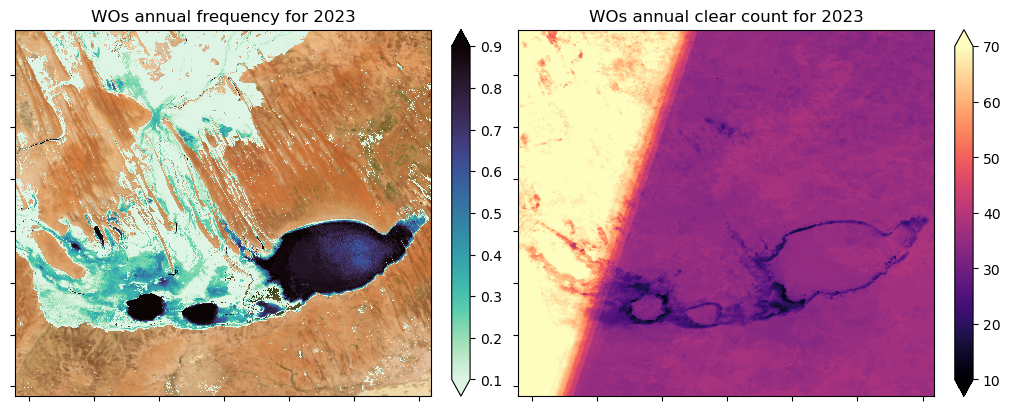

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), layout="constrained", sharey=True)
wo_cyear["frequency"].where(wo_cyear["frequency"] > 0).plot(
    ax=ax[0],
    cmap=sb.color_palette("mako_r", as_cmap=True),
    vmin=0.1,
    vmax=0.9,
    add_labels=False,
)
ctx.add_basemap(
    ax=ax[0],
    crs=wo_cyear.odc.crs,
    source=ctx.providers.Esri.WorldImagery,
    attribution="",
    attribution_size=1,
)
wo_cyear["count_clear"].plot(ax=ax[1], cmap="magma", add_labels=False, vmin=10, vmax=70)

ax[0].set_xticklabels(labels="")
ax[0].set_yticklabels(labels="")
ax[1].set_xticklabels(labels="")
ax[1].set_yticklabels(labels="")
ax[0].set_title("WOs annual frequency for 2023")
ax[1].set_title("WOs annual clear count for 2023");

### Load and plot the other summary periods

Now we will load all the other Water Observations Statistics products, and plot these in the subsequent cell to see how they differ from the 2023 calendar year summary we plotted above.

In [8]:
# Load Nov-Mar summaries from 2023
wo_nov_mar = dc.load(product="ga_ls_wo_fq_nov_mar_3", like=wo_cyear, time="2023-01")

# Load apr-oct summaries from 2023
wo_apr_oct = dc.load(product="ga_ls_wo_fq_apr_oct_3", like=wo_cyear, time="2023-07")

# Load the multi-year summary (1986-2025)
wo_myear = dc.load(product="ga_ls_wo_fq_myear_3", like=wo_cyear, time=time)

#### Plot the seasonal and multi-year summaries

The seasonal frequencies help us interpret what we saw above in the annual summary, while the 1986–2025 summary helps us understand what is typical for this location.

The multi-year Water Observations Statistics frequency (1986–2025; right) is predominantly low (pale cyan), showing that in this arid landscape surface water occurs only intermittently, with moderate water persistence limited to deeper water-holes and main channels. In contrast, 2023 exhibits markedly higher frequencies, especially in Apr–Oct 2023 (centre), indicating sustained inundation driven by higher rainfall and inflows from the upstream catchment following the 2022–23 wet season. 

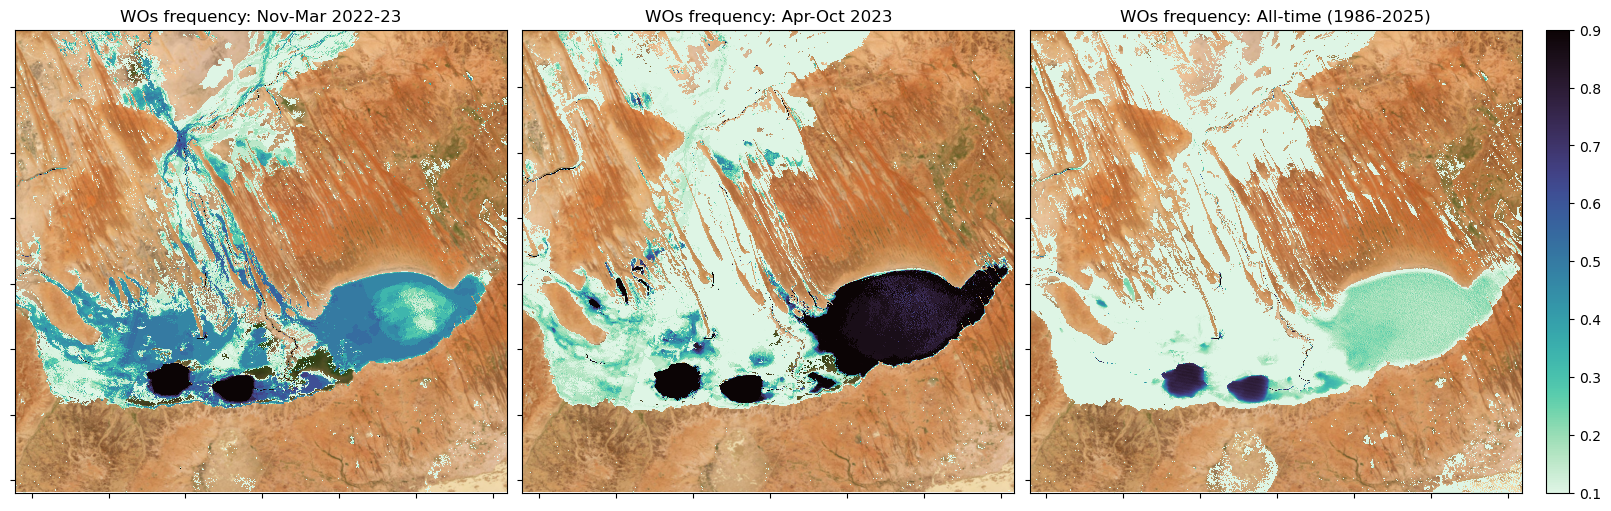

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), layout="constrained", sharey=True)

dss = [wo_nov_mar, wo_apr_oct, wo_myear]
titles = ["Nov-Mar 2022-23", "Apr-Oct 2023", "All-time (1986-2025)"]

for ax, ds, t in zip(axes.ravel(), dss, titles):
    im = (
        ds["frequency"]
        .where(ds["frequency"] > 0.01)  # help filter out noise
        .plot(
            ax=ax,
            cmap=sb.color_palette("mako_r", as_cmap=True),
            vmin=0.1,
            vmax=0.9,
            add_labels=False,
            add_colorbar=False,
        )
    )
    ctx.add_basemap(
        ax=ax,
        crs=wo_cyear.odc.crs,
        source=ctx.providers.Esri.WorldImagery,
        attribution="",
        attribution_size=1,
    )
    ax.set_xticklabels(labels="")
    ax.set_yticklabels(labels="")
    ax.set_title(f"WOs frequency: {t}")

# Add colorbar
cbar = plt.colorbar(im, ax=axes[2]);

## Example Application: Delineate a time series of lake shorelines

In this example, we will use the calendar year Water Observations Statistics product, `ga_ls_wo_fq_cyear_3`, to extract annual shorelines of Lake George, ACT, from 2013 to 2024. This will show us how the lake's shorelines have changed over this period in response to water availability (predominantly rainfall).

In [10]:
# Extent covers Lake George, ACT
lat, lon = -35.0989, 149.4252
buffer = 0.095
time = ("2013", "2024")

lat_range = (lat - buffer, lat + buffer)
lon_range = (lon - buffer, lon + buffer)

### Load calendar year Water Observations Statistics and geomedian data

Note we are loading a single year of the [DEA Geometric Median (Landsat)](https://knowledge.dea.ga.gov.au/data/product/dea-geometric-median-and-median-absolute-deviation-landsat/) product so we can plot our lake extents over a nice image of the region.

In [11]:
# Load calendar year Water Observations Statistics
wo_cyears = dc.load(
    product="ga_ls_wo_fq_cyear_3",
    x=lon_range,
    y=lat_range,
    time=time,
    output_crs="EPSG:3577",
    resolution=(-30, 30),
)

# Load Landsat 8/9 geomedian product for context
ds = dc.load(
    product="ga_ls8cls9c_gm_cyear_3",
    measurements=["nbart_red", "nbart_green", "nbart_blue"],
    like=wo_cyears,
    time="2024",
).squeeze()

### Find the outlines of the permanent water bodies

Here we set a threshold of 0.90, meaning if the Water Observations Statistics product observed water in a given pixel for more than 90 % of the year, then this pixel will be included in the annual shoreline extent of Lake George.

We will use the `dea_tools.spatial.subpixel_contours` function to extract the boundaries of Lake George from the image data. You can find out more about this function in the [Extracting contours](https://github.com/GeoscienceAustralia/dea-notebooks/blob/develop/How_to_guides/Contour_extraction.ipynb) notebook.

In [12]:
# Convert to a binary water/not-water image
threshold = 0.90
annual_water = xr.where(wo_cyears["frequency"] >= threshold, 1, 0)

# Extract contours into a geodataframe
water_bodies = subpixel_contours(annual_water, min_vertices=25, verbose=False)

# Add a simple 'year' column to help with the plotting
water_bodies["year"] = [i[0:4] for i in water_bodies.time]

### Plot the annual series of shorelines for Lake George

We also plot the 2024 Landsat geomedian beneath the shoreline contours to provide contextual background.

From the image below, it’s clear that the extent of Lake George has changed considerably over the past decade. In the most recent years (2022–2024), the lake has remained relatively full, whereas during the earlier part of the time series (2013–2019), it held significantly less water. The shifting shoreline positions reflect these variations in water level.

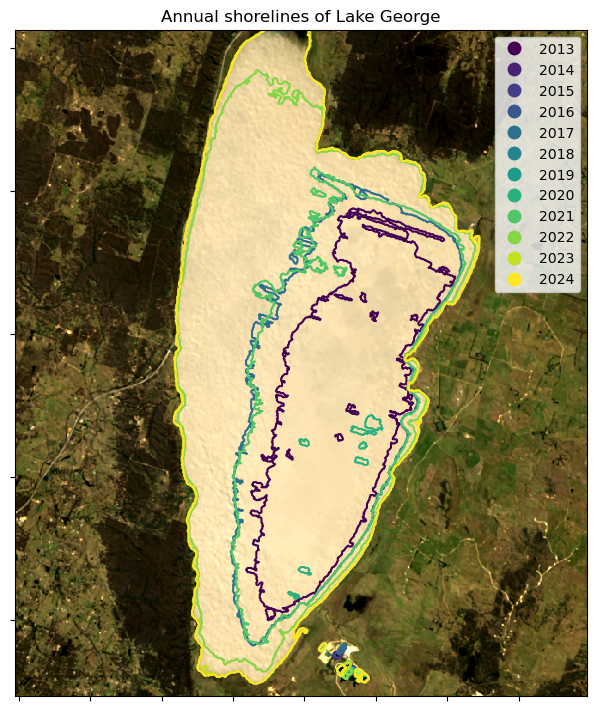

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(8, 7), layout="constrained")
ds[["nbart_red", "nbart_green", "nbart_blue"]].to_array().plot.imshow(
    robust=True, ax=ax, add_labels=False
)
water_bodies.plot(column="year", legend=True, cmap="viridis", ax=ax)
ax.set_xticklabels(labels="")
ax.set_yticklabels(labels="")
ax.set_title(f"Annual shorelines of Lake George");

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** February 2026

**Compatible datacube version:** 

In [14]:
print(datacube.__version__)

1.8.19


## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->